In [1]:
import pandas as pd
import numpy as np

In [2]:
df_rank_sum_merged = pd.read_excel('/data/project/yeonu/arpa_h/MSI_specific_with_median_expression.xlsx')
print(df_rank_sum_merged.shape)
print(df_rank_sum_merged.head())

(41, 22)
     gene  rank_sum_in_myeloid  rank_sum_in_eptheilal  rank_sum_in_plasma  \
0  S100A8                    5                  28476               28476   
1  S100A9                    5                  28476               28476   
2   IFI30                    5                  28476               28476   
3    FCN1                    5                  28476               28476   
4    VCAN                    5                  28476               28476   

   rank_sum_in_neutrophil  rank_sum_in_stromal  rank_sum_in_b_cell  \
0                    1301                28476               28476   
1                     671                28476               28476   
2                      64                28476                  76   
3                   28476                28476               28476   
4                   28476                 9839               28476   

   rank_sum_in_mast  myeloid/MSI_high  myeloid/MSS_high  ...  plasma/MSI_high  \
0             28476       

In [3]:
df_rank_sum_merged

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,myeloid/MSI_high,myeloid/MSS_high,...,plasma/MSI_high,plasma/MSS_high,neutrophil/MSI_high,neutrophil/MSS_high,stromal/MSI_high,stromal/MSS_high,B_cell/MSI_high,B_cell/MSS_high,mast/MSI_high,mast/MSS_high
0,S100A8,5,28476,28476,1301,28476,28476,28476,3.824363,0.473529,...,NaN,NaN,2.430002,2.99066,NaN,NaN,NaN,NaN,NaN,NaN
1,S100A9,5,28476,28476,671,28476,28476,28476,3.771781,1.369252,...,NaN,NaN,2.423087,3.32887,NaN,NaN,NaN,NaN,NaN,NaN
2,IFI30,5,28476,28476,64,28476,76,28476,2.308494,0.172113,...,NaN,NaN,0.000000,1.11679,NaN,NaN,0.000000,0.000000,NaN,NaN
3,FCN1,5,28476,28476,28476,28476,28476,28476,1.987435,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,VCAN,5,28476,28476,28476,9839,28476,28476,1.900609,0.000000,...,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
5,S100A12,5,28476,28476,28476,28476,28476,28476,1.609060,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,EIF4A1,5,1912,2457,28476,2893,1815,649,1.138457,0.204672,...,0.00000,0.0,NaN,NaN,0.927976,0.488287,0.580135,0.000000,0.896808,0.000000
7,AHNAK,5,6280,2762,28476,6625,5402,3448,1.267004,0.337085,...,0.02884,0.0,NaN,NaN,0.629842,0.786434,0.000000,0.000000,0.980667,0.861215
8,CRIP1,5,68,579,28476,9858,2962,2371,0.924856,0.000000,...,0.00000,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,CSF3R,5,28476,28476,180,28476,28476,28476,0.897823,0.000000,...,NaN,NaN,1.144749,1.98611,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ▶ Load expression matrix
expr_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/filtered_count_matrix/filtered_myeloid_count.csv"
expr_df = pd.read_csv(expr_path, index_col=0)

In [5]:
# ▶ Load metadata
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_myeloid_consensus.csv"
meta_df = pd.read_csv(meta_path)

In [6]:
meta_df

,cell_name,Group_born,Batch,Group
0,Che_2021-SRR14710630-AAAGATGAGAGGTAGA,MSS,Myeloid cell,MSS_high
1,Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,MSS,Myeloid cell,MSS_high
2,Che_2021-SRR14710630-AACCATGTCGTACCGG,MSS,Myeloid cell,MSS_high
3,Che_2021-SRR14710630-AACGTTGGTCTCCATC,MSS,Myeloid cell,MSS_high
4,Che_2021-SRR14710630-AAGACCTAGCCCAGCT,MSS,Myeloid cell,MSS_high
...,...,...,...,...
48407,Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,MSS,Myeloid cell,MSS_high
48408,Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,MSS,Myeloid cell,MSS_high
48409,Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,MSS,Myeloid cell,MSS_high
48410,Zheng_2022-GSM4904246-TTTACTGTCAGAAATG,MSS,Myeloid cell,MSS_high


In [8]:
gene_list = df_rank_sum_merged.head(20)['gene'].tolist()

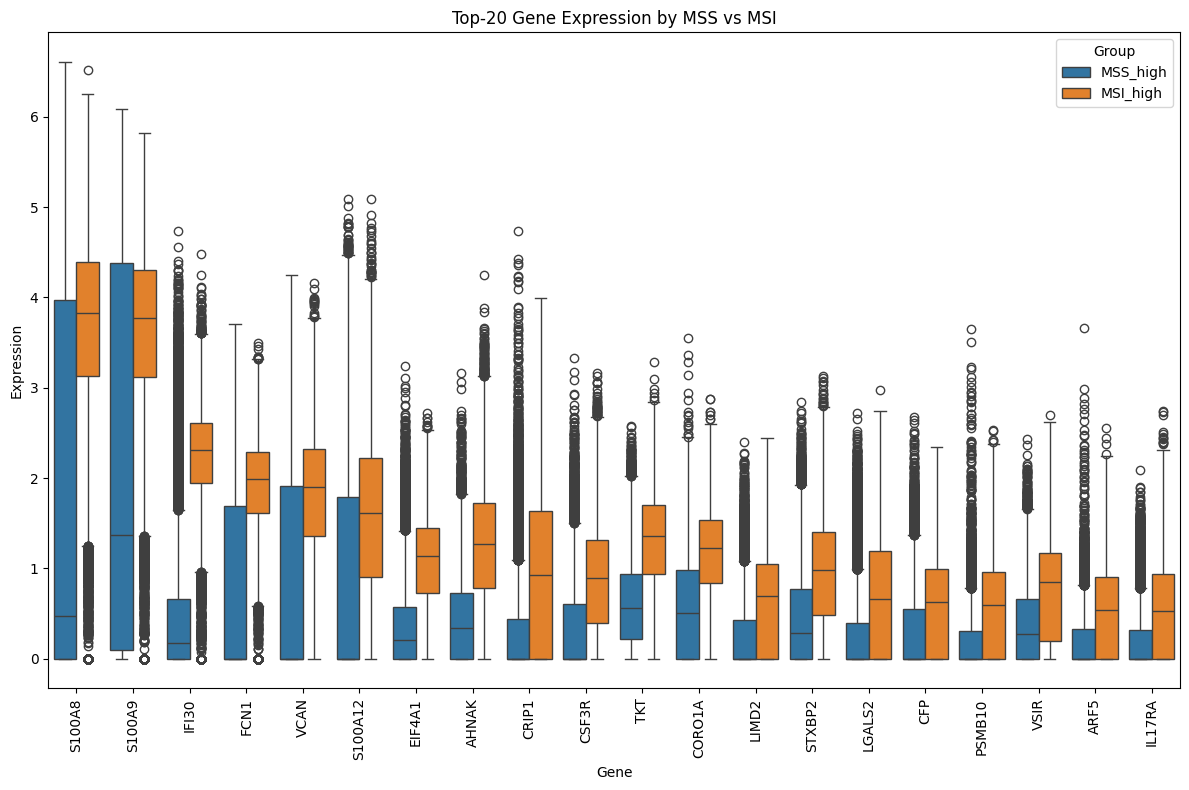

In [9]:
# 필요한 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Prepare expression + metadata for the top‑20 genes
expr = expr_df.loc[gene_list].T  # transpose so cells×genes
expr = expr.merge(meta_df[['cell_name','Group']], left_index=True, right_on='cell_name')

# Boxplot of expression for each gene split by MSS vs MSI
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=expr.melt(id_vars='Group', value_vars=gene_list, var_name='Gene', value_name='Expression'),
    x='Gene', y='Expression', hue='Group'
)
plt.xticks(rotation=90)
plt.title('Top‑20 Gene Expression by MSS vs MSI')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# 1) long 포맷으로 변환
expr_long = expr.melt(
    id_vars=['cell_name','Group'],
    value_vars=gene_list,
    var_name='Gene',
    value_name='Expression'
)

# 2) Gene×Group별 평균 발현 계산
group_summary = (
    expr_long
    .groupby(['Gene','Group'])['Expression']
    .mean()
    .unstack('Group')
)

# 3) Gene을 인덱스로, 원하는 순서인 gene_list 로 재색인
group_summary = group_summary.reindex(gene_list)

# 4) 인덱스를 다시 컬럼으로
group_summary = group_summary.reset_index().rename(columns={'index':'Gene'})

# 5) 컬럼 순서 정리 (필요 시)
group_summary = group_summary[['Gene','MSI_high','MSS_high']]

# 6) 결과 확인
print(group_summary)



Group     Gene  MSI_high  MSS_high
0       S100A8  3.674748  1.769609
1       S100A9  3.617693  2.124579
2        IFI30  2.220535  0.481830
3         FCN1  1.887689  0.754015
4         VCAN  1.789506  0.849130
5      S100A12  1.546555  0.807101
6       EIF4A1  1.034891  0.359966
7        AHNAK  1.232843  0.430195
8        CRIP1  0.990987  0.280108
9        CSF3R  0.868765  0.346526
10         TKT  1.264855  0.614621
11      CORO1A  1.127737  0.580727
12       LIMD2  0.639357  0.246979
13      STXBP2  0.945078  0.456090
14      LGALS2  0.670335  0.257284
15         CFP  0.588495  0.275917
16      PSMB10  0.561086  0.180785
17        VSIR  0.770113  0.371959
18        ARF5  0.515540  0.183608
19      IL17RA  0.538347  0.195210
